# Ropedia Academy — C2 · Key datasets: Ego4D, EPIC-Kitchens, EGTEA

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChaoYue0307/ropedia-academy/blob/main/notebooks/C2.ipynb)

> **Builds verb–noun actions with a leakage-free participant split and plots the long-tailed action-frequency distribution that defines egocentric benchmarks.**
>
> 构造动词–名词动作与无泄漏的按参与者划分，并画出定义第一人称基准的长尾动作频率分布。

This is the lesson's core example — **self-contained and runnable end to end**. It builds toy tensors, performs the lesson's key computation, and **visualizes the result with matplotlib** (the plot renders inline below the cell), so you learn the concept by executing and *seeing* it.

Colab's default runtime already includes `torch`, `numpy`, `networkx`, and `matplotlib`, so just press **Run all** — every cell goes green and a figure appears. Sizes are shrunk to run on CPU; swap in a real batch and the same code scales up.

🔗 Full lesson (with the interactive demo & key terms): https://chaoyue0307.github.io/ropedia-academy/lesson/C2

most common: [('take:onion', 23), ('take:knife', 21), ('cut:onion', 21)] | singletons: 0
participant-held-out split: train=202 test=98


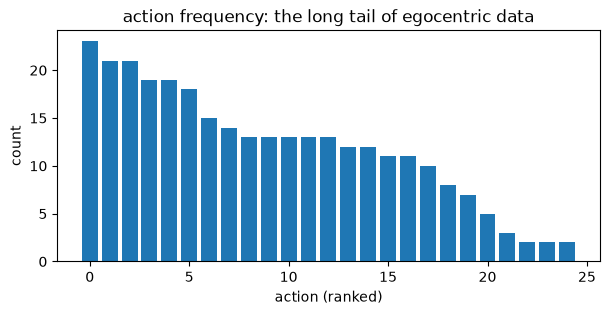

In [1]:
from collections import Counter
import random, matplotlib.pyplot as plt
# EPIC-style data: action=(verb,noun), long-tailed, split by participant.

# ---------- INPUT: 300 annotated (verb, noun, participant) clips ----------
random.seed(0)
verbs, nouns = ["take","put","cut","wash","open"], ["knife","onion","plate","tap","pan"]
anns = [(random.choice(verbs), random.choices(nouns, weights=[5,4,3,2,1])[0],
         f"P{random.randint(1,3):02d}") for _ in range(300)]

# ---------- MODEL: count the action distribution + a leakage-free split ----------
dist = Counter(f"{v}:{n}" for v, n, _ in anns)
test_p = {sorted({p for *_, p in anns})[-1]}
train = [a for a in anns if a[2] not in test_p]; test = [a for a in anns if a[2] in test_p]

# ---------- OUTPUT: stats + the long-tailed action-frequency bar chart ----------
print("most common:", dist.most_common(3), "| singletons:", sum(c==1 for c in dist.values()))
print(f"participant-held-out split: train={len(train)} test={len(test)}")
items = dist.most_common()
plt.figure(figsize=(7, 3))
plt.bar(range(len(items)), [c for _, c in items])
plt.title("action frequency: the long tail of egocentric data")
plt.xlabel("action (ranked)"); plt.ylabel("count"); plt.show()

### Where to go next

- Swap the toy tensors for a real batch and watch the shapes flow through.
- Open the matching lesson for the math and an interactive figure: https://chaoyue0307.github.io/ropedia-academy/lesson/C2
- Browse every notebook: https://github.com/ChaoYue0307/ropedia-academy/tree/main/notebooks